## Problem Statement

You need to build a model that is able to classify customer complaints based on the products/services. By doing so, you can segregate these tickets into their relevant categories and, therefore, help in the quick resolution of the issue.

You will be doing topic modelling on the <b>.json</b> data provided by the company. Since this data is not labelled, you need to apply NMF to analyse patterns and classify tickets into the following five clusters based on their products/services:

* Credit card / Prepaid card

* Bank account services

* Theft/Dispute reporting

* Mortgages/loans

* Others


With the help of topic modelling, you will be able to map each ticket onto its respective department/category. You can then use this data to train any supervised model such as logistic regression, decision tree or random forest. Using this trained model, you can classify any new customer complaint support ticket into its relevant department.

## Pipelines that needs to be performed:

You need to perform the following eight major tasks to complete the assignment:

1.  Data loading

2. Text preprocessing

3. Exploratory data analysis (EDA)

4. Feature extraction

5. Topic modelling

6. Model building using supervised learning

7. Model training and evaluation

8. Model inference

## Importing the necessary libraries

In [1]:
import json
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint

## Loading the data

The data is in JSON format and we need to convert it to a dataframe.

In [2]:
# Opening JSON file
f = open('complaints-2021-05-14_08_16.json')

# returns JSON object as
# a dictionary
data = json.load(f)
df=pd.json_normalize(data)

## Data preparation

In [3]:
# Inspect the dataframe to understand the given data.
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

The dataset has 78313 rows and 22 columns


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [4]:
#print the column names
df.columns

Index(['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.company_public_response',
       '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.sub_issue',
       '_source.consumer_consent_provided'],
      dtype='object')

In [5]:
#Assign new column names
# remove the '_source.' prefix that json_normalize added so the columns are easier to work with
df.columns = [col.replace('_source.', '') for col in df.columns]
df.columns

Index(['_index', '_type', '_id', '_score', 'tags', 'zip_code', 'complaint_id',
       'issue', 'date_received', 'state', 'consumer_disputed', 'product',
       'company_response', 'company', 'submitted_via', 'date_sent_to_company',
       'company_public_response', 'sub_product', 'timely',
       'complaint_what_happened', 'sub_issue', 'consumer_consent_provided'],
      dtype='object')

In [6]:
#Assign nan in place of blanks in the complaints column
df['complaint_what_happened'] = df['complaint_what_happened'].replace('', np.nan)

In [7]:
#Remove all rows where complaints column is nan
df = df[~df['complaint_what_happened'].isna()]
# reset the index after dropping rows
df = df.reset_index(drop=True)
print(f'Remaining complaints after removing blanks: {df.shape[0]}')

Remaining complaints after removing blanks: 21072


## Prepare the text for topic modeling

Once you have removed all the blank complaints, you need to:

* Make the text lowercase
* Remove text in square brackets
* Remove punctuation
* Remove words containing numbers


Once you have done these cleaning operations you need to perform the following:
* Lemmatize the texts
* Extract the POS tags of the lemmatized text and remove all the words which have tags other than NN[tag == "NN"].


In [8]:
# Write your function here to clean the text and remove all the unnecessary elements.
def clean_text(text):
    text = str(text).lower()                                         # make the text lowercase
    text = re.sub(r'\[.*?\]', '', text)                              # remove text in square brackets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # remove punctuation
    text = re.sub(r'\w*\d\w*', '', text)                             # remove words containing numbers
    text = re.sub(r'\s+', ' ', text).strip()                         # collapse extra whitespace
    return text

In [37]:
#Write your function to Lemmatize the texts
def lemmatize_text(doc):
    # doc is a spaCy Doc produced by nlp.pipe; join the lemma of every token
    return ' '.join([token.lemma_ for token in doc])

In [39]:
#Create a dataframe('df_clean') that will have only the complaints and the lemmatized complaints
df_clean = pd.DataFrame()
df_clean['complaint_what_happened'] = df['complaint_what_happened'].apply(clean_text)

# lemmatize via batched nlp.pipe (parser/ner disabled) for speed; lemmatize_text builds the string per Doc
lemmatized = [lemmatize_text(doc) for doc in nlp.pipe(df_clean['complaint_what_happened'].tolist(), batch_size=200, disable=['parser', 'ner'])]
df_clean['complaint_lemmatized'] = lemmatized

In [11]:
df_clean

,complaint_what_happened,complaint_lemmatized
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...
...,...,...
21067,after being a chase card customer for well ove...,after be a chase card customer for well over a...
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,on wednesday xxxxxxxx I call chas my xxxx xxxx...
21069,i am not familiar with xxxx pay and did not un...,I be not familiar with xxxx pay and do not und...
21070,i have had flawless credit for yrs ive had cha...,I have have flawless credit for yrs I ve have ...


In [40]:
#Write your function to extract the POS tags

def pos_tag(doc):
  # doc is a spaCy Doc; keep only tokens whose POS tag is a singular common noun (NN)
  return ' '.join([token.text for token in doc if token.tag_ == 'NN'])


# apply pos_tag on the lemmatized text via batched nlp.pipe (parser/ner disabled) for speed
#this column should contain lemmatized text with all the words removed which have tags other than NN[tag == "NN"].
pos_removed = [pos_tag(doc) for doc in nlp.pipe(df_clean['complaint_lemmatized'].tolist(), batch_size=200, disable=['parser', 'ner'])]
df_clean["complaint_POS_removed"] = pos_removed

In [41]:
#The clean dataframe should now contain the raw complaint, lemmatized complaint and the complaint after removing POS tags.
df_clean

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...,chase card report application identity consent...
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...,ticket offer ticket reward card information of...
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...
...,...,...,...
21067,after being a chase card customer for well ove...,after be a chase card customer for well over a...,chase card customer decade solicitation credit...
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,on wednesday xxxxxxxx I call chas my xxxx xxxx...,credit card provider claim purchase protection...
21069,i am not familiar with xxxx pay and did not un...,I be not familiar with xxxx pay and do not und...,pay risk consumer chase bank app chase year ba...
21070,i have had flawless credit for yrs ive had cha...,I have have flawless credit for yrs I ve have ...,credit yrs credit card chase freedom problem b...


## Exploratory data analysis to get familiar with the data.

Write the code in this task to perform the following:

*   Visualise the data according to the 'Complaint' character length
*   Using a word cloud find the top 40 words by frequency among all the articles after processing the text
*   Find the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text. ‘




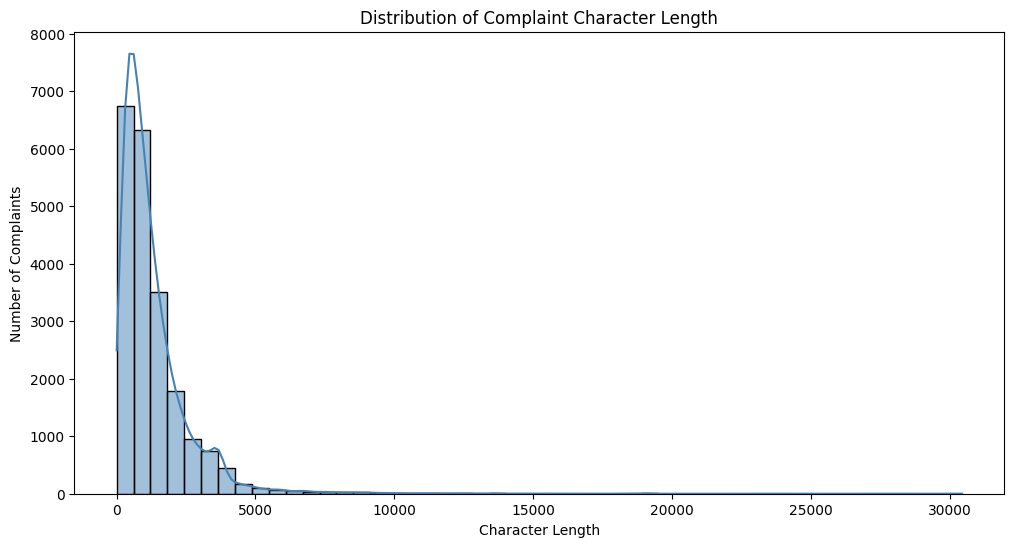

Observation- 
 Complaint length ranges from 0 to 30452 characters, with a median of 936 characters.


In [13]:
# Write your code here to visualise the data according to the 'Complaint' character length
char_length = df_clean['complaint_what_happened'].str.len()

plt.figure(figsize=(12, 6))
sns.histplot(char_length, bins=50, kde=True, color='steelblue')
plt.title('Distribution of Complaint Character Length')
plt.xlabel('Character Length')
plt.ylabel('Number of Complaints')
plt.show()

print("=" * 60)
print(f"Observation- \n Complaint length ranges from {char_length.min()} to {char_length.max()} characters, "
      f"with a median of {int(char_length.median())} characters.")
print("=" * 60)

#### Find the top 40 words by frequency among all the articles after processing the text.

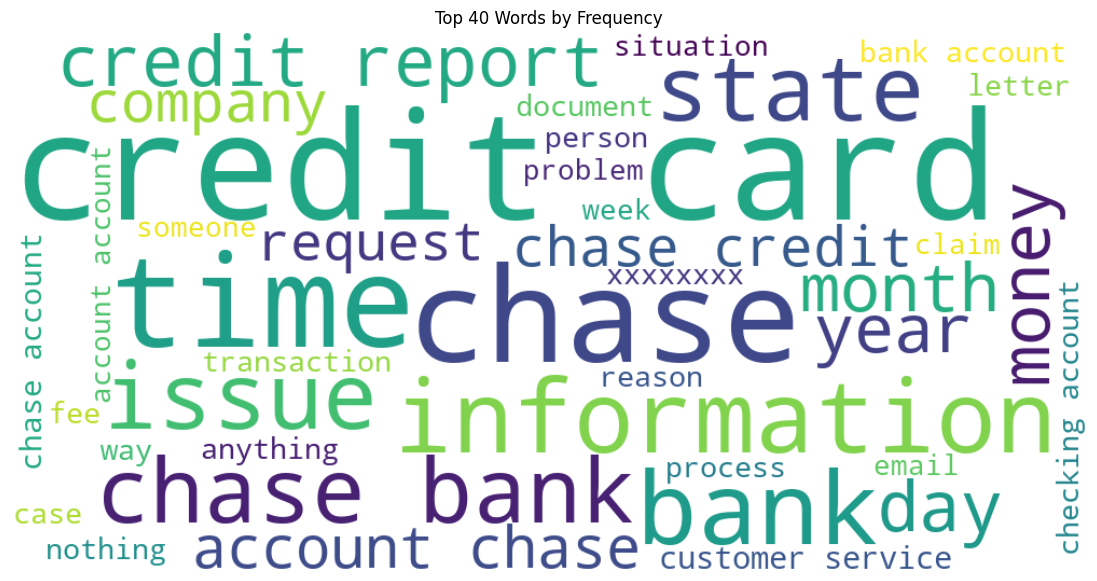

In [14]:
#Using a word cloud find the top 40 words by frequency among all the articles after processing the text
from wordcloud import WordCloud, STOPWORDS

# combine all the processed complaints into a single corpus
text_corpus = ' '.join(df_clean['complaint_POS_removed'].dropna())

wordcloud = WordCloud(max_words=40, background_color='white',
                      stopwords=set(STOPWORDS), width=1000, height=500,
                      random_state=42).generate(text_corpus)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words by Frequency')
plt.show()

In [15]:
#Removing -PRON- from the text corpus
df_clean['Complaint_clean'] = df_clean['complaint_POS_removed'].str.replace('-PRON-', '')

#### Find the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text.

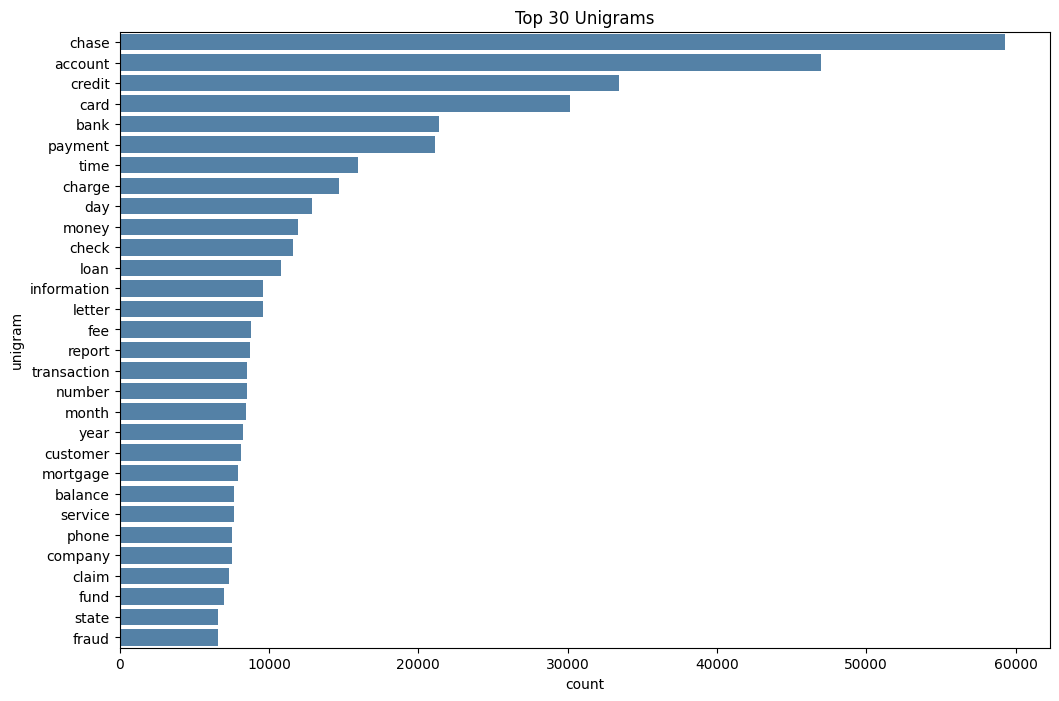

In [16]:
#Write your code here to find the top 30 unigram frequency among the complaints in the cleaned datafram(df_clean).

# helper to compute the top n n-grams by frequency
def get_top_ngram(corpus, ngram_range, n=30):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_unigrams = get_top_ngram(df_clean['Complaint_clean'], (1, 1), 30)
df_unigram = pd.DataFrame(top_unigrams, columns=['unigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='unigram', data=df_unigram, color='steelblue')
plt.title('Top 30 Unigrams')
plt.show()

In [17]:
#Print the top 10 words in the unigram frequency
df_unigram.head(10)

,unigram,count
0,chase,59312
1,account,46965
2,credit,33457
3,card,30143
4,bank,21392
5,payment,21140
6,time,15978
7,charge,14715
8,day,12904
9,money,11921


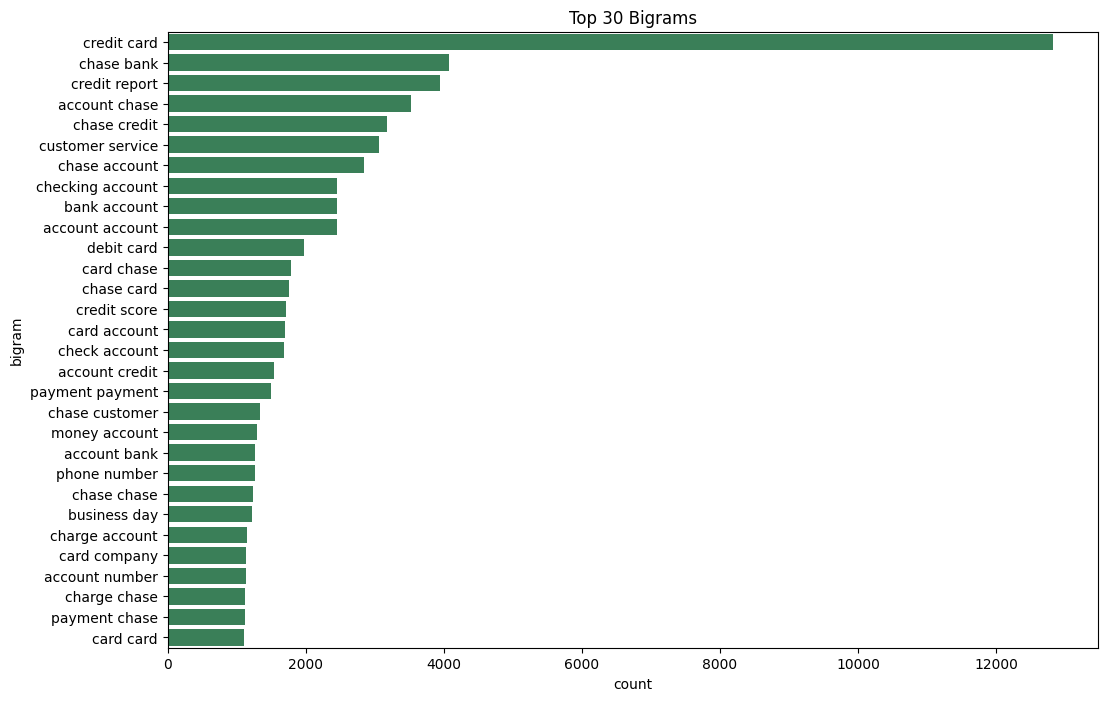

In [18]:
#Write your code here to find the top 30 bigram frequency among the complaints in the cleaned datafram(df_clean).
top_bigrams = get_top_ngram(df_clean['Complaint_clean'], (2, 2), 30)
df_bigram = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='bigram', data=df_bigram, color='seagreen')
plt.title('Top 30 Bigrams')
plt.show()

In [19]:
#Print the top 10 words in the bigram frequency
df_bigram.head(10)

,bigram,count
0,credit card,12832
1,chase bank,4070
2,credit report,3950
3,account chase,3524
4,chase credit,3174
5,customer service,3061
6,chase account,2850
7,checking account,2457
8,bank account,2451
9,account account,2449


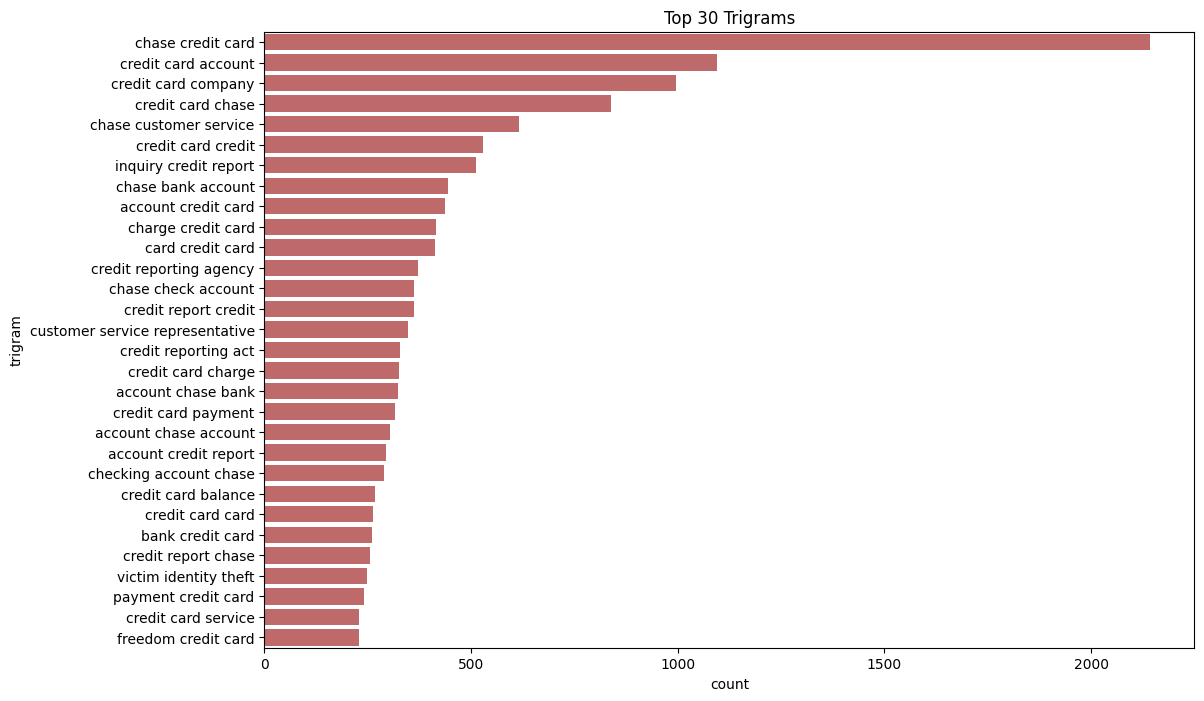

In [20]:
#Write your code here to find the top 30 trigram frequency among the complaints in the cleaned datafram(df_clean).
top_trigrams = get_top_ngram(df_clean['Complaint_clean'], (3, 3), 30)
df_trigram = pd.DataFrame(top_trigrams, columns=['trigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='trigram', data=df_trigram, color='indianred')
plt.title('Top 30 Trigrams')
plt.show()

In [21]:
#Print the top 10 words in the trigram frequency
df_trigram.head(10)

,trigram,count
0,chase credit card,2143
1,credit card account,1096
2,credit card company,996
3,credit card chase,839
4,chase customer service,616
5,credit card credit,528
6,inquiry credit report,513
7,chase bank account,445
8,account credit card,436
9,charge credit card,416


## The personal details of customer has been masked in the dataset with xxxx. Let's remove the masked text as this will be of no use for our analysis

In [22]:
df_clean['Complaint_clean'] = df_clean['Complaint_clean'].str.replace('xxxx','')

In [25]:
#All masked texts has been removed
df_clean

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed,Complaint_clean
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,morning name stop service debt verification st...
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,card agent anniversary date agent information ...
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...,chase card report application identity consent...,chase card report application identity consent...
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...,ticket offer ticket reward card information of...,ticket offer ticket reward card information of...
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...,son chase account fund chase bank account mone...
...,...,...,...,...
21067,after being a chase card customer for well ove...,after be a chase card customer for well over a...,chase card customer decade solicitation credit...,chase card customer decade solicitation credit...
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,on wednesday xxxxxxxx I call chas my xxxx xxxx...,credit card provider claim purchase protection...,credit card provider claim purchase protection...
21069,i am not familiar with xxxx pay and did not un...,I be not familiar with xxxx pay and do not und...,pay risk consumer chase bank app chase year ba...,pay risk consumer chase bank app chase year ba...
21070,i have had flawless credit for yrs ive had cha...,I have have flawless credit for yrs I ve have ...,credit yrs credit card chase freedom problem b...,credit yrs credit card chase freedom problem b...


## Feature Extraction
Convert the raw texts to a matrix of TF-IDF features

**max_df** is used for removing terms that appear too frequently, also known as "corpus-specific stop words"
max_df = 0.95 means "ignore terms that appear in more than 95% of the complaints"

**min_df** is used for removing terms that appear too infrequently
min_df = 2 means "ignore terms that appear in less than 2 complaints"

In [23]:
#Write your code here to initialise the TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')

#### Create a document term matrix using fit_transform

The contents of a document term matrix are tuples of (complaint_id,token_id) tf-idf score:
The tuples that are not there have a tf-idf score of 0

In [24]:
#Write your code here to create the Document Term Matrix by transforming the complaints column present in df_clean.
dtm = tfidf.fit_transform(df_clean['Complaint_clean'])
print(f'Document Term Matrix shape: {dtm.shape}')

Document Term Matrix shape: (21072, 6757)


## Topic Modelling using NMF

Non-Negative Matrix Factorization (NMF) is an unsupervised technique so there are no labeling of topics that the model will be trained on. The way it works is that, NMF decomposes (or factorizes) high-dimensional vectors into a lower-dimensional representation. These lower-dimensional vectors are non-negative which also means their coefficients are non-negative.

In this task you have to perform the following:

* Find the best number of clusters
* Apply the best number to create word clusters
* Inspect & validate the correction of each cluster wrt the complaints
* Correct the labels if needed
* Map the clusters to topics/cluster names

In [25]:
from sklearn.decomposition import NMF

## Manual Topic Modeling
You need to do take the trial & error approach to find the best num of topics for your NMF model.

The only parameter that is required is the number of components i.e. the number of topics we want. This is the most crucial step in the whole topic modeling process and will greatly affect how good your final topics are.

In [26]:
#Load your nmf_model with the n_components i.e 5
num_topics = 5 #write the value you want to test out

#keep the random_state =40
nmf_model = NMF(n_components=num_topics, random_state=40) #write your code here

In [27]:
nmf_model.fit(dtm)
len(tfidf.get_feature_names_out())

6757

In [28]:
#Print the Top15 words for each of the topics
words = np.array(tfidf.get_feature_names_out())

for i, topic in enumerate(nmf_model.components_):
    top_words = [words[j] for j in topic.argsort()[-15:]]
    print(f'Topic {i}:')
    print(top_words)
    print('-' * 60)

Topic 0:
['transfer', 'business', 'claim', 'number', 'transaction', 'checking', 'branch', 'day', 'deposit', 'fund', 'chase', 'money', 'bank', 'check', 'account']
------------------------------------------------------------
Topic 1:
['statement', 'company', 'time', 'merchant', 'balance', 'fraud', 'service', 'purchase', 'transaction', 'fee', 'dispute', 'credit', 'chase', 'charge', 'card']
------------------------------------------------------------
Topic 2:
['request', 'sale', 'house', 'foreclosure', 'rate', 'time', 'document', 'letter', 'year', 'property', 'modification', 'home', 'chase', 'mortgage', 'loan']
------------------------------------------------------------
Topic 3:
['limit', 'theft', 'bureau', 'application', 'identity', 'reporting', 'information', 'debt', 'company', 'score', 'account', 'card', 'inquiry', 'report', 'credit']
------------------------------------------------------------
Topic 4:
['error', 'mortgage', 'year', 'account', 'credit', 'date', 'chase', 'auto', 'time',

In [29]:
#Create the best topic for each complaint in terms of integer value 0,1,2,3 & 4
topic_results = nmf_model.transform(dtm)
best_topic = topic_results.argmax(axis=1)

In [30]:
#Assign the best topic to each of the cmplaints in Topic Column

df_clean['Topic'] = best_topic #write your code to assign topics to each rows.

In [34]:
df_clean.head()

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed,Complaint_clean,Topic
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,morning name stop service debt verification st...,2
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,1
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...,chase card report application identity consent...,chase card report application identity consent...,3
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...,ticket offer ticket reward card information of...,ticket offer ticket reward card information of...,3
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...,son chase account fund chase bank account mone...,0


In [35]:
#Print the first 5 Complaint for each of the Topics
# use a temporary view so df_clean itself is not truncated (needed later for supervised training)
df_clean.groupby('Topic').head(5).sort_values('Topic')

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed,Complaint_clean,Topic
6,with out notice jp morgan chase restricted my ...,with out notice jp morgan chase restrict my ac...,notice account debit card branch customer serv...,notice account debit card branch customer serv...,0
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...,son chase account fund chase bank account mone...,0
12,i opened an account with chase bank on xxxx an...,I open an account with chase bank on xxxx and ...,account bank code bonus term everything accoun...,account bank code bonus term everything accoun...,0
10,mishandling of this account by chase auto and ...,mishandle of this account by chase auto and xxxx,mishandle account auto,mishandle account auto,0
15,i opened the saving account for the bonus i wa...,I open the save account for the bonus I be sup...,save account bonus bonus auto transfer check t...,save account bonus bonus auto transfer check t...,0
8,on xxxx i made a payment to an online retailer...,on xxxx I make a payment to an online retailer...,payment retailer use chase pay chase website s...,payment retailer use chase pay chase website s...,1
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,1
13,to whom it may concern chase bank charged wron...,to whom it may concern chase bank charge wrong...,concern charge overdraft fee alert balance uns...,concern charge overdraft fee alert balance uns...,1
14,my chase amazon card was declined for a cateri...,my chase amazon card be decline for a catering...,chase amazon card decline catering order place...,chase amazon card decline catering order place...,1
16,xxxx xxxx a sofa love seat table and chairs an...,xxxx xxxx a sofa love seat table and chair and...,sofa love seat table chair debit card charge b...,sofa love seat table chair debit card charge b...,1


#### After evaluating the mapping, if the topics assigned are correct then assign these names to the relevant topic:
* Bank Account services
* Credit card or prepaid card
* Theft/Dispute Reporting
* Mortgage/Loan
* Others

In [31]:
#Create the dictionary of Topic names and Topics

# NOTE: this mapping is finalised after inspecting the Top-15 words of each NMF topic above.
Topic_names = {
    0: 'Bank Account services',
    1: 'Credit card or prepaid card',
    2: 'Others',
    3: 'Theft/Dispute Reporting',
    4: 'Mortgage/Loan'
}
#Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [37]:
df_clean

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed,Complaint_clean,Topic
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,morning name stop service debt verification st...,Others
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,Credit card or prepaid card
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...,chase card report application identity consent...,chase card report application identity consent...,Theft/Dispute Reporting
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...,ticket offer ticket reward card information of...,ticket offer ticket reward card information of...,Theft/Dispute Reporting
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...,son chase account fund chase bank account mone...,Bank Account services
...,...,...,...,...,...
21067,after being a chase card customer for well ove...,after be a chase card customer for well over a...,chase card customer decade solicitation credit...,chase card customer decade solicitation credit...,Credit card or prepaid card
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,on wednesday xxxxxxxx I call chas my xxxx xxxx...,credit card provider claim purchase protection...,credit card provider claim purchase protection...,Credit card or prepaid card
21069,i am not familiar with xxxx pay and did not un...,I be not familiar with xxxx pay and do not und...,pay risk consumer chase bank app chase year ba...,pay risk consumer chase bank app chase year ba...,Credit card or prepaid card
21070,i have had flawless credit for yrs ive had cha...,I have have flawless credit for yrs I ve have ...,credit yrs credit card chase freedom problem b...,credit yrs credit card chase freedom problem b...,Mortgage/Loan


## Supervised model to predict any new complaints to the relevant Topics.

You have now build the model to create the topics for each complaints.Now in the below section you will use them to classify any new complaints.

Since you will be using supervised learning technique we have to convert the topic names to numbers(numpy arrays only understand numbers)

In [32]:
#Create the dictionary again of Topic names and Topics

Topic_names = {
    'Bank Account services': 0,
    'Credit card or prepaid card': 1,
    'Others': 2,
    'Theft/Dispute Reporting': 3,
    'Mortgage/Loan': 4
}
#Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [39]:
df_clean

,complaint_what_happened,complaint_lemmatized,complaint_POS_removed,Complaint_clean,Topic
0,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,morning name stop service debt verification st...,2
1,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,1
2,chase card was reported on however fraudulent ...,chase card be report on however fraudulent app...,chase card report application identity consent...,chase card report application identity consent...,3
3,on while trying to book a xxxx xxxx ticket i c...,on while try to book a xxxx xxxx ticket I come...,ticket offer ticket reward card information of...,ticket offer ticket reward card information of...,3
4,my grand son give me check for i deposit it in...,my grand son give I check for I deposit it int...,son chase account fund chase bank account mone...,son chase account fund chase bank account mone...,0
...,...,...,...,...,...
21067,after being a chase card customer for well ove...,after be a chase card customer for well over a...,chase card customer decade solicitation credit...,chase card customer decade solicitation credit...,1
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,on wednesday xxxxxxxx I call chas my xxxx xxxx...,credit card provider claim purchase protection...,credit card provider claim purchase protection...,1
21069,i am not familiar with xxxx pay and did not un...,I be not familiar with xxxx pay and do not und...,pay risk consumer chase bank app chase year ba...,pay risk consumer chase bank app chase year ba...,1
21070,i have had flawless credit for yrs ive had cha...,I have have flawless credit for yrs I ve have ...,credit yrs credit card chase freedom problem b...,credit yrs credit card chase freedom problem b...,4


In [33]:
#Keep the columns"complaint_what_happened" & "Topic" only in the new dataframe --> training_data
training_data = df_clean[['complaint_what_happened', 'Topic']]

In [41]:
training_data

,complaint_what_happened,Topic
0,good morning my name is xxxx xxxx and i apprec...,2
1,i upgraded my xxxx xxxx card in and was told b...,1
2,chase card was reported on however fraudulent ...,3
3,on while trying to book a xxxx xxxx ticket i c...,3
4,my grand son give me check for i deposit it in...,0
...,...,...
21067,after being a chase card customer for well ove...,1
21068,on wednesday xxxxxxxx i called chas my xxxx xx...,1
21069,i am not familiar with xxxx pay and did not un...,1
21070,i have had flawless credit for yrs ive had cha...,4


####Apply the supervised models on the training data created. In this process, you have to do the following:
* Create the vector counts using Count Vectoriser
* Transform the word vecotr to tf-idf
* Create the train & test data using the train_test_split on the tf-idf & topics


In [34]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split

#Write your code to get the Vector count
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(training_data['complaint_what_happened'])

#Write your code here to transform the word vector to tf-idf
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_counts)

# create the train & test data on the tf-idf features and the topics
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, training_data['Topic'], test_size=0.25, random_state=42, stratify=training_data['Topic'])

print(f'Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')

Train samples: 15804, Test samples: 5268


You have to try atleast 3 models on the train & test data from these options:
* Logistic regression
* Decision Tree
* Random Forest
* Naive Bayes (optional)

**Using the required evaluation metrics judge the tried models and select the ones performing the best**

In [35]:
# Write your code here to build any 3 models and evaluate them using the required metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# map the integer topics back to readable names for the reports
label_names = ['Bank Account services', 'Credit card or prepaid card',
               'Others', 'Theft/Dispute Reporting', 'Mortgage/Loan']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1}

    print("=" * 60)
    print(f"{name}")
    print("=" * 60)
    print(f"  • Accuracy       : {acc:.4f}")
    print(f"  • Weighted F1    : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_names))

## Compare the models and pick the best one on weighted F1 score
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
for name, res in results.items():
    print(f"  • {name:<22}: Accuracy={res['accuracy']:.4f}, F1={res['f1']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_model_name]['model']
print("=" * 60)
print(f"Observation- \n Best performing model is '{best_model_name}' "
      f"with a weighted F1 score of {results[best_model_name]['f1']:.4f}")
print("=" * 60)

Logistic Regression
  • Accuracy       : 0.9273
  • Weighted F1    : 0.9270
                             precision    recall  f1-score   support

      Bank Account services       0.93      0.95      0.94      1411
Credit card or prepaid card       0.91      0.95      0.93      1575
                     Others       0.94      0.93      0.94       966
    Theft/Dispute Reporting       0.93      0.89      0.91       719
              Mortgage/Loan       0.95      0.85      0.89       597

                   accuracy                           0.93      5268
                  macro avg       0.93      0.91      0.92      5268
               weighted avg       0.93      0.93      0.93      5268

Decision Tree
  • Accuracy       : 0.7967
  • Weighted F1    : 0.7966
                             precision    recall  f1-score   support

      Bank Account services       0.81      0.82      0.82      1411
Credit card or prepaid card       0.80      0.82      0.81      1575
                     O

In [36]:
# Model inference: classify new customer complaints using the best performing model
inv_topic_names = {0: 'Bank Account services', 1: 'Credit card or prepaid card',
                   2: 'Others', 3: 'Theft/Dispute Reporting', 4: 'Mortgage/Loan'}

def predict_topic(complaint_text):
    cleaned = clean_text(complaint_text)
    counts = count_vect.transform([cleaned])
    features = tfidf_transformer.transform(counts)
    pred = best_model.predict(features)[0]
    return inv_topic_names[pred]

# try the model on a few new sample complaints
sample_complaints = [
    "I was charged an annual fee on my credit card that I was never told about.",
    "Someone made unauthorized transactions on my account and I want to report the fraud.",
    "My mortgage payment was applied to the wrong loan and my balance is incorrect.",
    "The bank closed my checking account without any prior notice or explanation."
]

for complaint in sample_complaints:
    print(f"Complaint : {complaint}")
    print(f"Predicted : {predict_topic(complaint)}")
    print("-" * 60)

Complaint : I was charged an annual fee on my credit card that I was never told about.
Predicted : Credit card or prepaid card
------------------------------------------------------------
Complaint : Someone made unauthorized transactions on my account and I want to report the fraud.
Predicted : Bank Account services
------------------------------------------------------------
Complaint : My mortgage payment was applied to the wrong loan and my balance is incorrect.
Predicted : Others
------------------------------------------------------------
Complaint : The bank closed my checking account without any prior notice or explanation.
Predicted : Bank Account services
------------------------------------------------------------
